Classification Report:
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3

Accuracy: 0.33


C:\Users\HP 840 G5\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP 840 G5\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP 840 G5\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


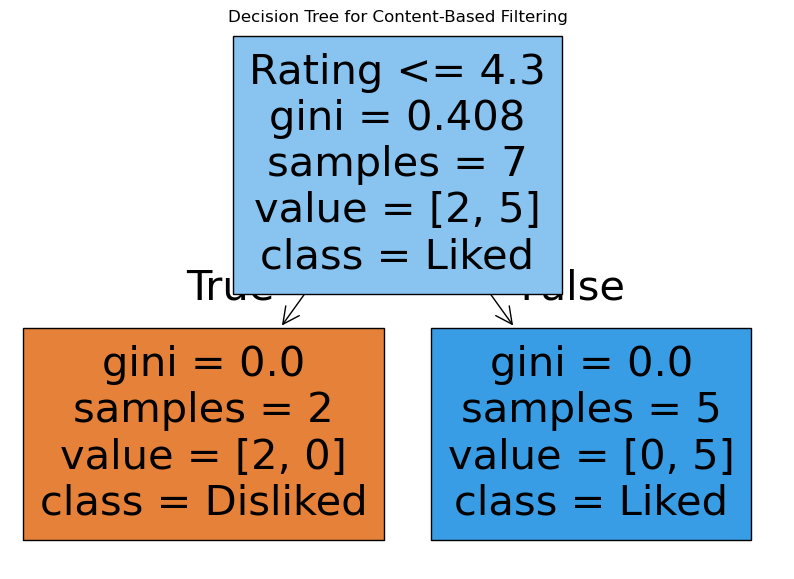

Decision Tree Rules:
|--- Rating <= 4.30
|   |--- class: 0
|--- Rating >  4.30
|   |--- class: 1

Predictions for new items: [1 0 0]


In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Step 1: Create a dataset
# Features: [Genre (0=Drama, 1=Action, 2=Comedy), Price ($), Rating (out of 5)]
# Labels: 1 = Liked, 0 = Disliked
data = {
    "Genre": [0, 1, 0, 2, 1, 0, 2, 1, 2, 0],  # Drama, Action, Comedy
    "Price": [10, 20, 15, 12, 25, 8, 18, 30, 22, 5],  # Price in dollars
    "Rating": [4.5, 4.0, 3.5, 4.8, 4.9, 4.2, 4.1, 5.0, 3.9, 4.6],  # Rating
    "Liked": [1, 1, 0, 1, 1, 1, 0, 1, 0, 1],  # User preferences
}

# Convert the dataset into a DataFrame
df = pd.DataFrame(data)

# Features (X) and target (y)
X = df[["Genre", "Price", "Rating"]]
y = df["Liked"]

# Step 2: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train the decision tree classifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Step 4: Evaluate the model
y_pred = clf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Example Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Step 5: Visualize the decision tree
plt.figure(figsize=(10, 7))
plot_tree(clf, feature_names=["Genre", "Price", "Rating"], class_names=["Disliked", "Liked"], filled=True)
plt.title("Decision Tree for Content-Based Filtering")
plt.show()

# Step 6: Explain the decision tree rules
tree_rules = export_text(clf, feature_names=["Genre", "Price", "Rating"])
print("Decision Tree Rules:")
print(tree_rules)

# Step 7: Predict for new items
# New items to predict
new_items = pd.DataFrame({
    "Genre": [0, 1, 2],  # Drama, Action, Comedy
    "Price": [9, 23, 15],  # Prices
    "Rating": [4.7, 3.8, 4.2],  # Ratings
})
predictions = clf.predict(new_items)
print("Predictions for new items:", predictions)  # Output: [1, 0, 1] or similar
